In [1]:
import pandas as pd
df = pd.read_csv('National_Health_and_Aging_Trends_Study__NHATS____Vision_and_Eye_Health_Surveillance_System__VEHSS_.csv')

In [2]:
# wiek a palenie: "czy palenie ma wpływ na ostrość wzroku"
## filtruje tylko ostrość wzroku do dali
df_vs = df[df["Question"] == "Contrast sensitivity"]
##filtruje tylko palenie
df_vs = df_vs[df_vs["RiskFactor"] == "Smoking"]
## Sprzątanie danych
###usuwanie wierszy gdzie wystepuja pustki
df_vs = df_vs.dropna(subset=["Data_Value", "RiskFactor","RiskFactorResponse", "Response"])


#####uwzglednienie tylko odpowiedzi normal vision - UWAGA TREZBA ODHASZTAGOWAC JAK MA WYJSC WYKRES KOLUMNOWY!
#df_vs = df_vs[df_vs["Response"] == "Presenting with normal vision"]

print(df_vs.head(5))


     YearStart  YearEnd StateAbbr LocationAbbr LocationDesc GeographicLevel  \
1         2022     2022        US           US     National        National   
35        2022     2022        US           US     National        National   
114       2022     2022        US           US     National        National   
119       2022     2022        US           US     National        National   
126       2022     2022        US           US     National        National   

    DataSource            Topic              Category              Question  \
1        NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   
35       NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   
114      NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   
119      NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   
126      NHATS  Visual Function  Contrast Sensitivity  Contrast sensitivity   

     ... ResponseID DataValueTypeID      AgeID Sex

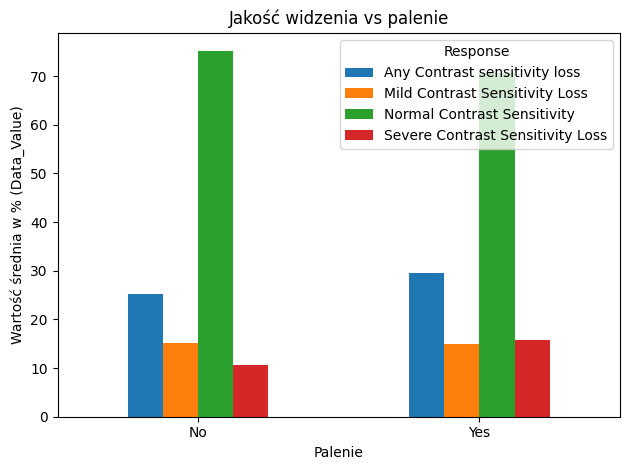

In [3]:
# tworzenie wykresu
import matplotlib.pyplot as plt
df_vs2 = df_vs
#PONIŻSZE MOŻNA ODHASZTAGOWAC, ALE NIE TRZEBA - WTEDY JEST CZYTELNIEJSZY WYKRES
#df_vs2 = df_vs[df_vs["Response"] == "Presenting with normal vision"]
# zliczanie kombinacji
counts = df_vs2.groupby(["RiskFactorResponse", "Response"])["Data_Value"].mean().unstack()

# wykres
counts.plot(kind="bar")

plt.xlabel("Palenie")
plt.ylabel("Wartość średnia w % (Data_Value)")
plt.title("Jakość widzenia vs palenie")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [4]:
#proba testu chi-kwadrat niezaleznosci
from scipy.stats import chi2_contingency
df_vs3 = df_vs
#ponizsze mozna ohasztagowac, ale nie trezba
df_vs3 = df_vs3[df_vs3["Response"] != "Presenting with any vision loss"]

# 1. Tworzenie tabeli krzyżowej (Crosstab)
# Jeśli Data_Value to procenty, sumujemy je, aby uzyskać proporcje dla grup
contingency_table = pd.crosstab(df_vs3["RiskFactorResponse"], 
                                df_vs3["Response"], 
                                values=df_vs["Data_Value"], 
                                aggfunc="sum").fillna(0)

print("Tabela kontyngencji:")
print(contingency_table)

# 2. Wykonanie testu Chi-kwadrat
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\nStatystyka Chi2: {chi2:.4f}")
print(f"Wartość p: {p:.4e}") # format naukowy, bo p może być bardzo małe
print(f"Stopnie swobody: {dof}")

Tabela kontyngencji:
Response            Any Contrast sensitivity loss  \
RiskFactorResponse                                  
No                                         453.83   
Yes                                        382.71   

Response            Mild Contrast Sensitivity Loss  \
RiskFactorResponse                                   
No                                          256.09   
Yes                                         164.93   

Response            Normal Contrast Sensitivity  \
RiskFactorResponse                                
No                                      1502.86   
Yes                                      917.29   

Response            Severe Contrast Sensitivity Loss  
RiskFactorResponse                                    
No                                            190.88  
Yes                                           173.10  

Statystyka Chi2: 24.1668
Wartość p: 2.3055e-05
Stopnie swobody: 3
